<center><font size=5><b>Extracting harmonics of $\phi$-dependent data in Gepard</b></font></center>

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys 
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import gepard as g

In [3]:
import gdevel as gd
print(gd.__version__)

0.9.11


In [4]:
import os
import subprocess
branch = subprocess.check_output(['git', '-C', os.path.dirname(gd.__file__),
                                  'branch', '--show-current']).decode('ascii').strip()
revhash = subprocess.check_output(['git', '-C', os.path.dirname(gd.__file__),
                                   'rev-parse', 'HEAD']).decode('ascii').strip()
print('Current git branch is "{}" and revision hash is {}'.format(branch, revhash))

Current git branch is "devel" and revision hash is 6a29f18c7246e4172fd8540814631d1b4fdb0f4a


In [5]:
def plotpts(bin1, bin2=None, replica=None):
    """Plot points in bin with errorbars."""
    fig, ax = plt.subplots(1,1, figsize=[6,6])
    ax.errorbar(bin1.phi.values, bin1.val.values, bin1.err.values, color='blue', linestyle='None',
               capsize=3)
    if isinstance(bin2, pd.DataFrame):
        ax.errorbar(bin2.phi.values, bin2.val.values, bin2.err.values, color='red', linestyle='None',
                   capsize=2)
    if isinstance(replica, np.ndarray):
        ax.plot(bin1.phi.values, replica, marker='o', color='red', linestyle='None')
    ax.set_ylim(-0.5, 0.5)
    ax.set_xlim(-np.pi, np.pi)
    fig.savefig('fig')

In [6]:
def plotFT(dfs, cosmax, sinmax):
    """Plot harmonics with with errorbars."""
    CM = cosmax
    SM = sinmax
    fig, ax = plt.subplots(1,1, figsize=[6,6])
    shift = 0
    for df in dfs:
        c = df.val.values[:CM+1]
        delc = df.err.values[:CM+1]
        s = df.val.values[CM+1:CM+SM+1]
        dels = df.err.values[CM+1:CM+SM+1]
        ax.errorbar(np.arange(CM+1)+shift, c, delc, linestyle='None', capsize=3,color='blue')
        ax.errorbar(np.arange(-1,-SM-1,-1)+shift, s, dels, linestyle='None', capsize=3, color='red')
        shift += 0.05
    ax.axhline(linestyle='-.', color='green', linewidth=0.5)
    ax.axvline(linestyle='-.', color='green', linewidth=0.5)
    #ax.legend(loc=4, fontsize=14).draw_frame(1)
    fig.savefig('fig')

## Basic extraction of harmonics (CLAS $A_{\rm LU}$) 

In [7]:
#sys.path.append('/Users/higuera-admin/Documents/Programs/ldrdgff/gepard/src/gepard/')
sys.path.append('/Users/higuera-admin/Documents/Programs/ldrdgff/gepardDevel/gdevel/src/gdevel')
import mydatafiles
from mydatafiles import ep2epgamma

mydset = gd.data.loaddata(mydatafiles)
mydset.update(gd.data.loaddata(ep2epgamma))

In [8]:
fitpoints = mydset[160] # mydset[192] #mydset[270]
g.describe_data(fitpoints)

npt x obs     collab  FTn    id  ref.        
----------------------------------------------
6016 x XUU     CLAS    N/A    160 arxiv.org/pdf/1810.02110
----------------------------------------------
TOTAL = 6016


In [9]:
dfALU = mydset[160].df()[['Q2', 'xB', 'tm', 'phi', 'val', 'errstat', 'errsyst']]
#dfALU = mydset[191].df()[['Q2', 'xB', 'tm', 'phi', 'val', 'errstat', 'errsyst']]
#dfALU = g.dset[139].df()[['Q2', 'xB', 'tm', 'phi', 'val', 'errstat', 'errsyst']]
#dfALL = mydset[270].df()[['Q2', 'xB', 'tm', 'phi', 'val', 'errstat', 'errsyst']]

Gepard's FT routines below work with `err` as uncertainty to be FT-transformed. This
should be only statistical uncertainty, while systematic uncertainty should be added
in quadrature after FT (if you don't decide to do some even more sophisticated approach).
Thus we rename column with statistical uncertainties as `err`:

In [10]:
dfALU.rename(columns={'errstat': 'err'}, inplace=True)

Now we detect bins. (This will not work like this if mean values of bin kinematic variables are not exactly the same. In that case you have to write more sophisticated algorithm or define bins manually.)

In [11]:
all_bins = dfALU[['Q2', 'xB', 'tm']].drop_duplicates()
bins = all_bins.reset_index(drop=True)
print('Number of all bins = {}'.format(len(bins)))

Number of all bins = 1250


Organize bins in Python directory. (This will include `phi`, `val` and `err` as well.)

In [12]:
binALU = {}
for k in range(len(bins)):
    # binALU[k] = dfALU[np.all(dfALU[['Q2', 'xB', 'tm']] == bins.iloc[k], axis=1)]
    binALU[k] = dfALU[dfALU[['Q2', 'xB', 'tm']].values == bins.iloc[k].values].drop_duplicates()

There is a Gepard function `FTFMC` that will, for given bin, by default extract all harmonics using discrete Fourier transform and Monte Carlo uncertainty propagation.

In [13]:
binALU[0]

,Q2,xB,tm,phi,val,err,errsyst
0,1.129,0.125,0.108,1.968731,4.833600,0.331067,0.869408
1,1.128,0.124,0.108,1.708677,4.480890,0.230636,0.267920
2,1.128,0.124,0.108,1.446878,3.673560,0.199450,0.259276
3,1.128,0.124,0.108,1.183333,2.722190,0.174966,0.288682
4,1.129,0.124,0.108,0.919789,2.601130,0.188421,0.235225
...,...,...,...,...,...,...,...
3984,1.936,0.215,0.108,-0.130900,-0.022829,0.026916,0.019128
3985,1.936,0.215,0.108,-0.394444,0.004084,0.031480,0.013399
3986,1.936,0.215,0.108,-0.656244,-0.004477,0.036897,0.013020
3987,1.935,0.215,0.108,-0.919789,-0.057269,0.032055,0.012912


In [14]:
dfFT = gd.data.FTFMC(binALU[1])

Be careful. Dataframe that is returned still has `phi` values but they don't make sense here (they are just kept for later cross-check). First (N-1/2) values are cosine harmonics, and rest are sine:

In [15]:
dfFT

,phi,val,err
0,1.968731,1.636046,0.286437
1,1.708677,-0.675256,0.124379
2,1.446878,-1.127176,0.217512
3,1.183333,1.465436,0.283775
4,0.919789,0.138588,0.034691
...,...,...,...
195,-0.130900,0.572426,0.391512
196,-0.394444,0.206554,0.185133
197,-0.656244,-0.686163,0.510673
198,-0.919789,0.366093,0.241904


So here above sin($\phi$) harmonic is in row index 5. You can plot all of them:

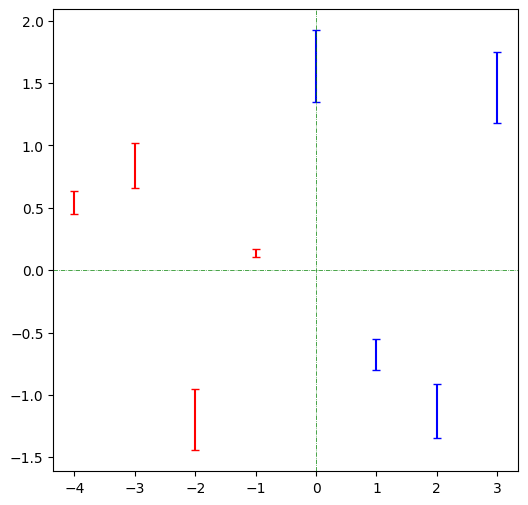

In [20]:
plotFT([dfFT], cosmax=3, sinmax=4)

`FTFMC(df, inverse=True)` will do the inverse FT so you can check the whole procedure for consistency:

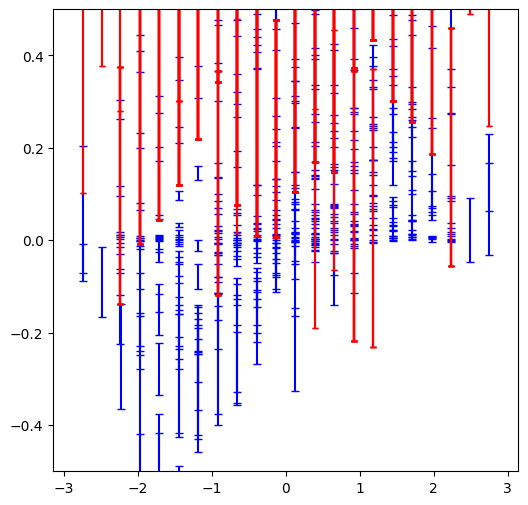

In [31]:
plotpts(binALU[0], gd.data.FTFMC(gd.data.FTFMC(binALU[0]), inverse=True))

There is also a somewhat experimental function `FTanalyse` that can take a set of bins and determine by cross-validation procedure how many harmonics are "visible" in this data:

In [22]:
cosmax, sinmax = gd.data.FTanalyse(binALU)

Highest extractable cos harmonic = 1.583 +- 0.584
Highest extractable sin harmonic = 0.816 +- 0.765



For final harmonic analysis we increase the number of Monte Carlo samples and store the results in two new dataframe columns:

In [24]:
for k in range(len(bins)):
    dfFT = gd.data.FTFMC(binALU[k], nsamples = 3000)
    binALU[k]['FTval'] = pd.Series(dfFT['val'].values, index=binALU[k].index)
    binALU[k]['FTerr'] = pd.Series(dfFT['err'].values, index=binALU[k].index)

In [25]:
binALU[4]

,Q2,xB,tm,phi,val,err,errsyst,FTval,FTerr
0,1.129,0.125,0.108,1.968731,4.833600,0.331067,0.869408,0.051879,0.025943
1,1.128,0.124,0.108,1.708677,4.480890,0.230636,0.267920,0.270381,0.025224
2,1.128,0.124,0.108,1.446878,3.673560,0.199450,0.259276,0.133085,0.021715
3,1.128,0.124,0.108,1.183333,2.722190,0.174966,0.288682,-0.092912,0.028539
4,1.129,0.124,0.108,0.919789,2.601130,0.188421,0.235225,0.579785,0.041235
...,...,...,...,...,...,...,...,...,...
4972,2.656,0.305,0.153,0.919789,0.004051,0.012189,0.000657,0.215553,0.205961
4973,2.658,0.305,0.153,0.656244,0.065742,0.034124,0.006408,0.273611,0.586244
4974,2.658,0.305,0.153,-0.656244,-0.035654,0.017621,0.002190,-0.446934,0.675460
4975,2.656,0.305,0.153,-0.919789,-0.010797,0.015757,0.002422,0.156449,0.057172


In [26]:
def s1(bin):
    """Take just first sine harmonic of bin with error."""
    s1ind = int((len(bin)-1)/2.) + 1 # index of first sine harmonic
    return bin[['Q2', 'xB', 'tm', 'FTval', 'FTerr']].iloc[s1ind]

We unite all bins, taking value and uncertainty of just calculated first sine harmonic (FTval and FTerr), and
we also calculate average and maximal systematic error for given bin. One can than choose which of the two
to take as the proper systematic error of the harmonic (more sophisticated treatment could be implemented here by the person who understands systematics better).

In [27]:
FTs1 = pd.DataFrame([pd.concat([s1(binALU[k]),
                                pd.Series([binALU[k]['errsyst'].mean(),
                                                     binALU[k]['errsyst'].max()], index=['avgsyst', 'maxsyst'])])
                     for k in bins.index]).reset_index(drop=True)

This (after maybe some reduction of significant digits) can now be saved into the new Gepard datafile with appropriate preamble:

In [28]:
FTs1['FTval'] = FTs1['FTval'].map(lambda x: '%.3f' % x)
FTs1['FTerr'] = FTs1['FTerr'].map(lambda x: '%.3f' % x)
FTs1['FTerrsyst'] = FTs1['avgsyst'].map(lambda x: '%.3f' % x)   # choose maxsyst to be conservative

In [29]:
print(FTs1[['Q2', 'xB', 'tm', 'FTval', 'FTerr', 'FTerrsyst']].to_string(index=False))

   Q2    xB    tm        FTval       FTerr FTerrsyst
1.904 0.216 0.108       -0.058       0.028     0.060
1.129 0.125 0.108       -0.391       0.298     0.098
1.129 0.125 0.108       -0.424       0.151     0.100
1.128 0.124 0.108        0.067       0.041     0.045
1.129 0.125 0.108       -0.068       0.023     0.054
1.129 0.125 0.108        0.036       0.005     0.112
1.487 0.186 0.152        0.090       0.013     0.046
1.128 0.124 0.108        0.020       0.002     0.066
2.425 0.365 0.203       -0.011       0.006     0.030
2.425 0.365 0.203       -0.012       0.006     0.026
3.271 0.399 0.263        4.664       0.597     0.056
3.055 0.365 0.262       -0.009       0.005     0.026
1.426 0.155 0.261        0.098       0.014     0.035
1.426 0.155 0.261        0.108       0.015     0.035
2.416 0.275 0.340        0.020       0.007     0.033
2.416 0.275 0.340        0.019       0.009     0.033
3.091 0.460 0.451       -0.651       0.214     0.035
1.426 0.156 0.446        0.071       0.010    

Such procedure was followed to create the mydatafiles ID=182 (some lines are commented out
in that datafile):

In [ ]:
#print(mydset[182].df()[['Q2', 'xB', 'tm', 'val', 'errstat', 'errsyst']].to_string(index=False))

     Q2      xB      tm    val  errstat  errsyst
1.17098 0.09829 0.29026  0.085    0.039      0.0
1.23055 0.23951 0.34267 -0.885    1.082      0.0
1.16069 0.09807 0.55942  0.156    0.032      0.0
1.20139 0.16075 0.58099  0.004    0.097      0.0
1.22297 0.23502 0.63939  0.229    0.735      0.0
1.16971 0.09702 1.05316  0.766    0.185      0.0
1.60576 0.15599 0.31425 -0.246    0.479      0.0
1.54972 0.11304 0.56128  0.318    0.147      0.0
1.59735 0.16169 0.58224  0.285    0.257      0.0
1.60562 0.25015 0.64407  0.160    0.071      0.0
2.01347 0.14258 0.29988  0.281    0.328      0.0
2.12931 0.19307 0.32879  0.630    0.188      0.0
2.00625 0.14243 0.56632  0.273    0.244      0.0
2.10837 0.19527 0.59712  0.098    0.287      0.0
2.11950 0.31098 0.67478  0.049    0.127      0.0
2.14984 0.29989 1.25910  0.133    0.165      0.0
2.68499 0.18571 0.32106  0.295    0.379      0.0
2.84675 0.25492 0.36339  0.519    0.336      0.0
2.66791 0.18912 0.57114 -0.318    0.657      0.0
2.83258 0.25276 0.63